# 01. 데이터 수집 및 전처리 — MinMaxScaler 기반 (실험 1)

## 실험 개요

이 노트북은 Patron 프로젝트의 첫 번째 단계다. NASDAQ 100과 S&P 100의 합집합인 **172개 미국 대형주**의 주봉 OHLC 데이터를 수집하고, 12주 슬라이딩 윈도우로 잘라 **약 50,000개의 차트 패턴**을 생성한다. 각 패턴은 MinMaxScaler로 0~1 범위로 정규화한 뒤 224×224 그레이스케일 캔들스틱 이미지로 변환한다.

이 노트북에서 선택한 MinMaxScaler 방식이 실험 1(채택)의 전처리 기준이다. 실험 3(Log 정규화)과의 비교는 07 노트북에서 수행한다.

## 하이퍼파라미터 설정 근거

| 항목 | 값 | 근거 |
|---|---|---|
| 유니버스 | NASDAQ 100 + S&P 100 합집합 | 대형주 중심으로 유동성과 데이터 품질 확보 |
| 기간 | 2020-01-01 ~ 현재 | 코로나 급락 포함, 다양한 시장 국면 확보 |
| 윈도우 크기 | 12주 (3개월) | 단기 추세를 담기에 적합한 최소 단위 |
| 슬라이딩 스텝 | 1주 | 패턴 다양성 최대화 |
| 정규화 방식 | MinMaxScaler | 패턴 내 상대 위치를 [0, 1]로 표현, 가격 절대값 무관 |
| 이미지 크기 | 224×224 | ResNet18 기본 입력 해상도 |
| 대비 강화 | 1.5배 | 흑백 이미지에서 캔들 형태를 더 명확히 표현 |
| 수익률 레이블 | 3M / 6M / 12M | 패턴 종료 후 성과 분석용 참조 데이터 |

## 결과

총 **49,987개 패턴 생성** (172개 종목 × 평균 295개)

## 1. 종목 유니버스 구성

NASDAQ 100과 S&P 100의 합집합으로 172개 대형주 리스트를 구성한다. 두 지수는 상당 부분 겹치므로 `set()` 연산으로 중복을 제거하면 172개의 고유 종목이 남는다. 여기에 시장 지수 자체(^IXIC, ^GSPC)를 추가해 지수와 개별 종목 패턴을 함께 검색할 수 있게 한다.

알파벳 순 정렬은 이후 파일 저장·로드 순서를 일관되게 유지하기 위함이다.

In [ ]:
# ============================================
# Phase 1 - Step 1: 티커 수집
# ============================================

# 1단계: 나스닥 100 티커 추출 (101개)
# https://www.nasdaq.com/market-activity/quotes/nasdaq-ndx-index
# 사이트는 알파벳 오름차순 정렬되어있음
nasdaq_100 = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META',
    'TSLA', 'PLTR', 'NFLX', 'AMD', 'ASML', 'COST', 'CSCO', 'AZN',
    'MU', 'TMUS', 'SHOP', 'APP', 'PEP', 'LRCX', 'LIN', 'QCOM',
    'PDD', 'INTC', 'ISRG', 'INTU', 'AMAT', 'ARM', 'BKNG', 'AMGN',
    'KLAC', 'PANW', 'GILD', 'TXN', 'ADBE', 'CRWD', 'HON', 'MELI',
    'CEG', 'ADI', 'VRTX', 'DASH', 'ADP', 'CMCSA', 'CDNS', 'SBUX',
    'SNPS', 'MRVL', 'ORLY', 'ABNB', 'MSTR', 'MDLZ', 'CTAS', 'MAR',
    'TRI', 'REGN', 'CSX', 'FTNT', 'MNST', 'PYPL', 'AEP', 'ADSK',
    'WDAY', 'AXON', 'DDOG', 'WBD', 'NXPI', 'ZS', 'ROST', 'PCAR',
    'IDXX', 'EA', 'XEL', 'ROP', 'BKR', 'TTWO', 'FAST', 'EXC',
    'TEAM', 'PAYX', 'CPRT', 'FANG', 'CCEP', 'KDP', 'CTSH', 'GEHC',
    'MCHP', 'VRSK', 'CHTR', 'ODFL', 'KHC', 'CSGP', 'TTD', 'DXCM',
    'BIIB', 'CDW', 'ON', 'LULU', 'GFS'
]
nasdaq_100 = sorted(nasdaq_100)


# 2단계: S&P 100 티커 추출 (100개)
# https://www.tradingview.com/symbols/SP-OEX/components/
# 사이트는 알파벳 오름차순 정렬 안되어있음
sp_100 = [
    'NVDA', 'AAPL', 'MSFT', 'GOOGL', 'GOOG', 'AMZN', 'AVGO', 'META',
    'TSLA', 'BRK-B', 'JPM', 'LLY', 'WMT', 'ORCL', 'V', 'MA',
    'XOM', 'PLTR', 'NFLX', 'JNJ', 'AMD', 'COST', 'BAC', 'ABBV',
    'HD', 'PG', 'GE', 'CVX', 'UNH', 'KO', 'CSCO', 'IBM',
    'WFC', 'CAT', 'MS', 'AXP', 'CRM', 'RTX', 'GS', 'TMUS',
    'PM', 'ABT', 'MRK', 'TMO', 'MCD', 'DIS', 'UBER', 'PEP',
    'LIN', 'QCOM', 'NOW', 'ISRG', 'INTC', 'C', 'INTU', 'T',
    'BLK', 'SCHW', 'NEE', 'VZ', 'BKNG', 'AMGN', 'ACN', 'BA',
    'DHR', 'GILD', 'TXN', 'ADBE', 'PFE', 'COF', 'LOW', 'UNP',
    'HON', 'DE', 'MDT', 'LMT', 'COP', 'SO', 'CMCSA', 'CVS',
    'DUK', 'NKE', 'MO', 'BMY', 'GD', 'SBUX', 'MMM', 'AMT',
    'UPS', 'EMR', 'BK', 'MDLZ', 'USB', 'PYPL', 'GM', 'CL',
    'FDX', 'SPG', 'MET', 'AIG'
]
print(f'nasdaq_100의 종목 개수는 {len(nasdaq_100)}개입니다')
print(f'sp_100의 종목 개수는 {len(sp_100)}개입니다')



# 3단계: 합집합 처리 (중복 제거)
all_tickers = list(set(nasdaq_100 + sp_100))

# 4단계: 지수 2개 추가
all_tickers.extend(['^IXIC', '^GSPC'])

# 5단계: 알파벳 순 정렬
all_tickers.sort()


print(all_tickers)

print(f"총 종목 수: {len(all_tickers)}개")

nasdaq_100의 종목 개수는 101개입니다
sp_100의 종목 개수는 100개입니다
['AAPL', 'ABBV', 'ABNB', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'AIG', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'APP', 'ARM', 'ASML', 'AVGO', 'AXON', 'AXP', 'AZN', 'BA', 'BAC', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLK', 'BMY', 'BRK-B', 'C', 'CAT', 'CCEP', 'CDNS', 'CDW', 'CEG', 'CHTR', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CPRT', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTSH', 'CVS', 'CVX', 'DASH', 'DDOG', 'DE', 'DHR', 'DIS', 'DUK', 'DXCM', 'EA', 'EMR', 'EXC', 'FANG', 'FAST', 'FDX', 'FTNT', 'GD', 'GE', 'GEHC', 'GFS', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'IDXX', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KDP', 'KHC', 'KLAC', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'LULU', 'MA', 'MAR', 'MCD', 'MCHP', 'MDLZ', 'MDT', 'MELI', 'MET', 'META', 'MMM', 'MNST', 'MO', 'MRK', 'MRVL', 'MS', 'MSFT', 'MSTR', 'MU', 'NEE', 'NFLX', 'NKE', 'NOW', 'NVDA', 'NXPI', 'ODFL', 'ON', 'ORCL', 'ORLY', 'PANW', 'PAYX', 'PCAR', 'PDD', 'PEP', 'P

## 2. 주봉 OHLC 데이터 수집

yfinance를 사용해 172개 종목의 2020-01-01 이후 주봉 데이터를 내려받고 Google Drive에 종목별 CSV로 저장한다.

주봉을 선택한 이유는 일봉 대비 노이즈가 적고 12주 윈도우가 약 3개월의 중기 추세를 담기 때문이다. 멀티인덱스를 제거해 OHLC 4열만 남기며, 실패한 종목은 별도 목록에 기록해 재시도를 쉽게 한다.

In [ ]:
# ============================================
# Phase 1 - Step 2: 주가 데이터 수집 (전체 172개)
# ============================================

!pip install yfinance -q

import yfinance as yf
import pandas as pd
import os
from datetime import datetime
from google.colab import drive

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 저장 경로 설정
BASE_PATH = '/content/drive/MyDrive/Patron/data/raw'
os.makedirs(BASE_PATH, exist_ok=True)
print(f"✅ 저장 경로: {BASE_PATH}\n")

# 전체 172개 종목
FULL_TICKERS = all_tickers  # 위에서 만든 172개 리스트

print(f"🚀 데이터 수집 시작: {len(FULL_TICKERS)}개 종목")
print(f"기간: 2020-01-01 ~ {datetime.now().strftime('%Y-%m-%d')}")
print(f"형식: 각 종목당 305주 × 4열 (OHLC)")
print("=" * 60)

success_count = 0
fail_count = 0
failed_tickers = []

for i, ticker in enumerate(FULL_TICKERS, 1):
    try:
        # 진행상황 출력 (같은 줄에)
        print(f"[{i:3d}/{len(FULL_TICKERS)}] {ticker:8s} 다운로드 중...", end=" ")

        # yfinance로 주봉 데이터 다운로드
        data = yf.download(
            ticker,
            start='2020-01-01',
            interval='1wk',
            progress=False,
            auto_adjust=True
        )

        if not data.empty:
            # OHLC만 추출
            ohlc_data = data[['Open', 'High', 'Low', 'Close']].copy()

            # 멀티인덱스 제거 (깔끔하게!)
            ohlc_data.columns = ['Open', 'High', 'Low', 'Close']

            # CSV 저장 (기존 파일 있으면 덮어쓰기)
            file_path = f"{BASE_PATH}/{ticker}.csv"
            ohlc_data.index.name = "Date"
            ohlc_data.to_csv(file_path)

            print(f"✅ ({len(ohlc_data):3d}주)")
            success_count += 1
        else:
            print(f"❌ 데이터 없음")
            fail_count += 1
            failed_tickers.append(ticker)

    except Exception as e:
        print(f"❌ 에러: {str(e)[:40]}")
        fail_count += 1
        failed_tickers.append(ticker)

# 최종 결과
print("\n" + "=" * 60)
print(f"🎉 수집 완료!\n")
print(f"✅ 성공: {success_count}개")
print(f"❌ 실패: {fail_count}개")

if failed_tickers:
    print(f"\n⚠️  실패 종목 리스트:")
    for ticker in failed_tickers:
        print(f"   - {ticker}")

# 샘플 확인
if success_count > 0:
    print(f"\n📊 샘플 데이터 확인 (첫 번째 성공 종목):")
    first_success = [t for t in FULL_TICKERS if t not in failed_tickers][0]
    sample = pd.read_csv(f"{BASE_PATH}/{first_success}.csv", index_col=0)
    print(f"\n종목: {first_success}")
    print(sample.head())
    print(f"\nShape: {sample.shape}")
    print(f"기간: {sample.index[0]} ~ {sample.index[-1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 저장 경로: /content/drive/MyDrive/Patron/data/raw

🚀 데이터 수집 시작: 172개 종목
기간: 2020-01-01 ~ 2025-11-07
형식: 각 종목당 305주 × 4열 (OHLC)
[  1/172] AAPL     다운로드 중... ✅ (306주)
[  2/172] ABBV     다운로드 중... ✅ (306주)
[  3/172] ABNB     다운로드 중... ✅ (257주)
[  4/172] ABT      다운로드 중... ✅ (306주)
[  5/172] ACN      다운로드 중... ✅ (306주)
[  6/172] ADBE     다운로드 중... ✅ (306주)
[  7/172] ADI      다운로드 중... ✅ (306주)
[  8/172] ADP      다운로드 중... ✅ (306주)
[  9/172] ADSK     다운로드 중... ✅ (306주)
[ 10/172] AEP      다운로드 중... ✅ (306주)
[ 11/172] AIG      다운로드 중... ✅ (306주)
[ 12/172] AMAT     다운로드 중... ✅ (306주)
[ 13/172] AMD      다운로드 중... ✅ (306주)
[ 14/172] AMGN     다운로드 중... ✅ (306주)
[ 15/172] AMT      다운로드 중... ✅ (306주)
[ 16/172] AMZN     다운로드 중... ✅ (306주)
[ 17/172] APP      다운로드 중... ✅ (239주)
[ 18/172] ARM      다운로드 중... ✅ (113주)
[ 19/172] ASML     다운로드 중... ✅ (306주)
[ 20/172] AVGO     다운로드 

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ORCL']: Timeout('Failed to perform, curl: (28) Operation timed out after 10002 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


❌ 데이터 없음
[124/172] ORLY     다운로드 중... ✅ (306주)
[125/172] PANW     다운로드 중... ✅ (306주)
[126/172] PAYX     다운로드 중... ✅ (306주)
[127/172] PCAR     다운로드 중... ✅ (306주)
[128/172] PDD      다운로드 중... ✅ (306주)
[129/172] PEP      다운로드 중... ✅ (306주)
[130/172] PFE      다운로드 중... ✅ (306주)
[131/172] PG       다운로드 중... ✅ (306주)
[132/172] PLTR     다운로드 중... ✅ (267주)
[133/172] PM       다운로드 중... ✅ (306주)
[134/172] PYPL     다운로드 중... ✅ (306주)
[135/172] QCOM     다운로드 중... ✅ (306주)
[136/172] REGN     다운로드 중... ✅ (306주)
[137/172] ROP      다운로드 중... ✅ (306주)
[138/172] ROST     다운로드 중... ✅ (306주)
[139/172] RTX      다운로드 중... ✅ (306주)
[140/172] SBUX     다운로드 중... ✅ (306주)
[141/172] SCHW     다운로드 중... ✅ (306주)
[142/172] SHOP     다운로드 중... ✅ (306주)
[143/172] SNPS     다운로드 중... ✅ (306주)
[144/172] SO       다운로드 중... ✅ (306주)
[145/172] SPG      다운로드 중... ✅ (306주)
[146/172] T        다운로드 중... ✅ (306주)
[147/172] TEAM     다운로드 중... ✅ (306주)
[148/172] TMO      다운로드 중... ✅ (306주)
[149/172] TMUS     다운로드 중... ✅ (306주)
[15

## 3. 수집 결과 확인

저장된 CSV 파일 개수와 전체 용량을 확인한다. 종목당 약 306주 데이터에서 12주 윈도우를 1주씩 이동하면 295개 패턴이 생성되므로, 172개 종목 기준 총 약 50,740개 패턴이 예상된다.

In [ ]:
# ============================================
# 셀 3: 생성된 파일 개수 확인
# ============================================

import os

BASE_PATH = '/content/drive/MyDrive/Patron/data/raw'

# CSV 파일만 카운트
csv_files = [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')]

print("=" * 60)
print(f"📁 생성된 CSV 파일 개수: {len(csv_files)}개")
print("=" * 60)

# 파일 리스트 출력 (첫 10개만)
print(f"\n📝 파일 목록 (처음 10개):")
for i, file in enumerate(sorted(csv_files)[:10], 1):
    file_path = f"{BASE_PATH}/{file}"
    file_size = os.path.getsize(file_path) / 1024  # KB로 변환
    print(f"   {i:2d}. {file:15s} ({file_size:6.1f} KB)")

if len(csv_files) > 10:
    print(f"   ... 외 {len(csv_files) - 10}개")

# 전체 용량 계산
total_size = sum(os.path.getsize(f"{BASE_PATH}/{f}") for f in csv_files)
total_size_mb = total_size / (1024 * 1024)

print(f"\n💾 전체 용량: {total_size_mb:.2f} MB")

# 예상 패턴 개수 계산
if csv_files:
    sample = pd.read_csv(f"{BASE_PATH}/{csv_files[0]}", index_col=0)
    weeks = len(sample)
    patterns_per_stock = weeks - 12 + 1
    total_patterns = len(csv_files) * patterns_per_stock

    print(f"\n📊 데이터 통계:")
    print(f"   - 종목 수: {len(csv_files)}개")
    print(f"   - 주봉 수: {weeks}주")
    print(f"   - 패턴/종목: {patterns_per_stock}개")
    print(f"   - 총 패턴: {total_patterns:,}개")

📁 생성된 CSV 파일 개수: 172개

📝 파일 목록 (처음 10개):
    1. AAPL.csv        (  25.5 KB)
    2. ABBV.csv        (  25.3 KB)
    3. ABNB.csv        (  20.1 KB)
    4. ABT.csv         (  25.4 KB)
    5. ACN.csv         (  25.2 KB)
    6. ADBE.csv        (  23.4 KB)
    7. ADI.csv         (  25.5 KB)
    8. ADP.csv         (  25.5 KB)
    9. ADSK.csv        (  24.3 KB)
   10. AEP.csv         (  24.8 KB)
   ... 외 162개

💾 전체 용량: 4.11 MB

📊 데이터 통계:
   - 종목 수: 172개
   - 주봉 수: 306주
   - 패턴/종목: 295개
   - 총 패턴: 50,740개


## 4. 섹터 및 산업군 정보 수집

172개 종목 각각의 섹터와 산업군 정보를 yfinance에서 가져와 CSV로 저장한다.

이 메타데이터는 검색 결과 화면에 "Technology / Consumer Electronics" 같은 부가 정보를 표시하는 데 사용된다. 학습에는 직접 사용하지 않지만 결과 해석에 중요한 역할을 한다.

In [ ]:
# ============================================
# Phase 1 - Step 3-1: Sector/Industry 수집
# ============================================

import yfinance as yf
import pandas as pd
from tqdm import tqdm
import time

# 모든 티커에 대해 sector/industry 수집
ticker_info_list = []

print("📊 Sector/Industry 정보 수집 중...")
for ticker in tqdm(all_tickers):
    try:
        info = yf.Ticker(ticker).info
        ticker_info_list.append({
            'ticker': ticker,
            'sector': info.get('sector', 'Unknown'),
            'industry': info.get('industry', 'Unknown')
        })
        time.sleep(0.1)  # API 부담 줄이기
    except:
        ticker_info_list.append({
            'ticker': ticker,
            'sector': 'Unknown',
            'industry': 'Unknown'
        })

# DataFrame으로 변환
ticker_info_df = pd.DataFrame(ticker_info_list)

# 저장
SECTOR_PATH = '/content/drive/MyDrive/Patron/data/ticker_info.csv'
ticker_info_df.to_csv(SECTOR_PATH, index=False)

print(f"✅ 저장 완료: {SECTOR_PATH}")
print(ticker_info_df.head())

📊 Sector/Industry 정보 수집 중...


100%|██████████| 172/172 [01:09<00:00,  2.47it/s]

✅ 저장 완료: /content/drive/MyDrive/Patron/data/ticker_info.csv
  ticker             sector                         industry
0   AAPL         Technology             Consumer Electronics
1   ABBV         Healthcare     Drug Manufacturers - General
2   ABNB  Consumer Cyclical                  Travel Services
3    ABT         Healthcare                  Medical Devices
4    ACN         Technology  Information Technology Services


## 5. 슬라이딩 윈도우 패턴 생성 및 정규화

12주 슬라이딩 윈도우로 OHLC 데이터를 잘라 패턴을 만들고, 각 윈도우 단위로 MinMaxScaler를 적용해 0~1 범위로 정규화한다.

MinMaxScaler를 윈도우 단위로 적용하는 이유는 **절대 가격 수준에 무관하게 패턴 형태만 비교**하기 위해서다. 예를 들어 $10짜리 패턴과 $1,000짜리 패턴이 같은 모양이면 같은 임베딩 공간에 위치해야 한다. 패턴 종료 후 3개월·6개월·12개월 수익률도 함께 저장해 나중에 "이 패턴 이후 평균 수익률" 분석에 활용한다.

In [ ]:
# ============================================
# Phase 1 - Step 3-2: 슬라이딩 윈도우 + 완전판 메타데이터
# ============================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os
from tqdm import tqdm

# 경로 설정
RAW_PATH = '/content/drive/MyDrive/Patron/data/raw'
PROCESSED_PATH = '/content/drive/MyDrive/Patron/data/processed'
SECTOR_PATH = '/content/drive/MyDrive/Patron/data/ticker_info.csv'
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Sector/Industry 정보 로드
ticker_info_df = pd.read_csv(SECTOR_PATH)
ticker_info_dict = ticker_info_df.set_index('ticker').to_dict('index')

# 윈도우 설정
WINDOW_SIZE = 12

print("=" * 60)
print("🔄 Phase 1 - Step 3: 패턴 생성 + 완전판 메타데이터")
print("=" * 60)
print(f"윈도우 크기: {WINDOW_SIZE}주\n")

# CSV 파일 리스트
csv_files = sorted([f for f in os.listdir(RAW_PATH) if f.endswith('.csv')])

all_metadata = []  # 전체 메타데이터 (하나의 CSV로 합칠 예정)
success_count = 0
total_patterns = 0

for csv_file in tqdm(csv_files, desc="Processing"):
    try:
        # CSV 읽기
        ticker = csv_file.replace('.csv', '')
        df = pd.read_csv(f"{RAW_PATH}/{csv_file}", index_col=0)

        # Sector/Industry 정보
        sector = ticker_info_dict.get(ticker, {}).get('sector', 'Unknown')
        industry = ticker_info_dict.get(ticker, {}).get('industry', 'Unknown')

        # OHLC 데이터
        ohlc = df[['Open', 'High', 'Low', 'Close']].values

        # 슬라이딩 윈도우
        patterns = []
        num_patterns = len(ohlc) - WINDOW_SIZE + 1

        for i in range(num_patterns):
            # 12주 윈도우 추출
            window = ohlc[i:i+WINDOW_SIZE]

            # 정규화
            scaler = MinMaxScaler()
            normalized_window = scaler.fit_transform(window)
            patterns.append(normalized_window)

            # 인덱스 계산
            start_idx = i
            end_idx = i + WINDOW_SIZE - 1

            # 가격 정보
            start_price = df.iloc[start_idx]['Close']
            end_price = df.iloc[end_idx]['Close']

            # 이후 수익률 계산
            idx_3m = end_idx + 12
            idx_6m = end_idx + 24
            idx_12m = end_idx + 52

            return_3m = ((df.iloc[idx_3m]['Close'] - end_price) / end_price * 100) if idx_3m < len(df) else None
            return_6m = ((df.iloc[idx_6m]['Close'] - end_price) / end_price * 100) if idx_6m < len(df) else None
            return_1y = ((df.iloc[idx_12m]['Close'] - end_price) / end_price * 100) if idx_12m < len(df) else None

            # 메타데이터 추가
            all_metadata.append({
                'ticker': ticker,
                'pattern_id': i,
                'start_date': df.index[start_idx],
                'end_date': df.index[end_idx],
                'start_price': start_price,
                'end_price': end_price,
                'sector': sector,
                'industry': industry,
                'return_3m': return_3m,
                'return_6m': return_6m,
                'return_1y': return_1y
            })

        # Numpy 배열 저장
        patterns_array = np.array(patterns)
        np.save(f"{PROCESSED_PATH}/{ticker}.npy", patterns_array)

        success_count += 1
        total_patterns += len(patterns)

    except Exception as e:
        print(f"\n❌ {ticker} 처리 실패: {e}")

# 전체 메타데이터를 하나의 CSV로 저장
metadata_df = pd.DataFrame(all_metadata)
metadata_df.to_csv(f"{PROCESSED_PATH}/metadata_all.csv", index=False)

# 결과 출력
print("\n" + "=" * 60)
print("🎉 처리 완료!")
print("=" * 60)
print(f"✅ 성공: {success_count}/{len(csv_files)}개")
print(f"📊 총 패턴: {total_patterns:,}개")
print(f"💾 메타데이터: {PROCESSED_PATH}/metadata_all.csv\n")

# 샘플 확인
print("📝 메타데이터 샘플:")
print(metadata_df.head(10))
print(f"\nShape: {metadata_df.shape}")


## 결과물

# /content/drive/MyDrive/Patron/data/
# ├── ticker_info.csv          # sector/industry 매핑
# ├── raw/
# │   ├── AAPL.csv
# │   └── ...
# └── processed/
#     ├── AAPL.npy            # 패턴 데이터
#     ├── MSFT.npy
#     ├── ...
#     └── metadata_all.csv    # 전체 메타데이터 ⭐

🔄 Phase 1 - Step 3: 패턴 생성 + 완전판 메타데이터
윈도우 크기: 12주



Processing: 100%|██████████| 172/172 [00:51<00:00,  3.32it/s]



🎉 처리 완료!
✅ 성공: 172/172개
📊 총 패턴: 49,987개
💾 메타데이터: /content/drive/MyDrive/Patron/data/processed/metadata_all.csv

📝 메타데이터 샘플:
  ticker  pattern_id  start_date    end_date  start_price  end_price  \
0   AAPL           0  2020-01-01  2020-03-18    72.065163  59.766296   
1   AAPL           1  2020-01-08  2020-03-25    75.516373  61.560165   
2   AAPL           2  2020-01-15  2020-04-01    76.455864  62.804489   
3   AAPL           3  2020-01-22  2020-04-08    76.726357  69.490913   
4   AAPL           4  2020-01-29  2020-04-15    77.006500  64.968719   
5   AAPL           5  2020-02-05  2020-04-22    77.190048  67.440430   
6   AAPL           6  2020-02-12  2020-04-29    77.225594  72.035240   
7   AAPL           7  2020-02-19  2020-05-06    69.740273  75.388145   
8   AAPL           8  2020-02-26  2020-05-13    70.040459  76.012161   
9   AAPL           9  2020-03-04  2020-05-20    69.076942  76.883591   

       sector              industry  return_3m  return_6m   return_1y  
0  Technol

## 6. 이미지 생성 방식 비교

캔들스틱 이미지를 생성하는 세 가지 방법을 시각적으로 비교한다: matplotlib 직접 그리기, mplfinance 원본, mplfinance + 대비 1.5배.

모델이 차트 **모양**을 학습하려면 일관된 시각적 표현이 필요하다. matplotlib는 캔들 꼬리가 끊기는 문제가 있어 제외하고, mplfinance + 대비 강화 방식이 캔들 형태를 가장 명확하게 표현함을 확인한다.

입력 데이터: (12, 4)
값 범위: 0.000 ~ 1.000

🎨 이미지 생성 중...
✅ matplotlib: (224, 224)
✅ mplfinance (원본): (224, 224)
✅ mplfinance (대비↑): (224, 224)



/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 44844 (\N{HANGUL SYLLABLE GGO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 45130 (\N{HANGUL SYLLABLE GGEUNH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-448777543.py:125: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layou

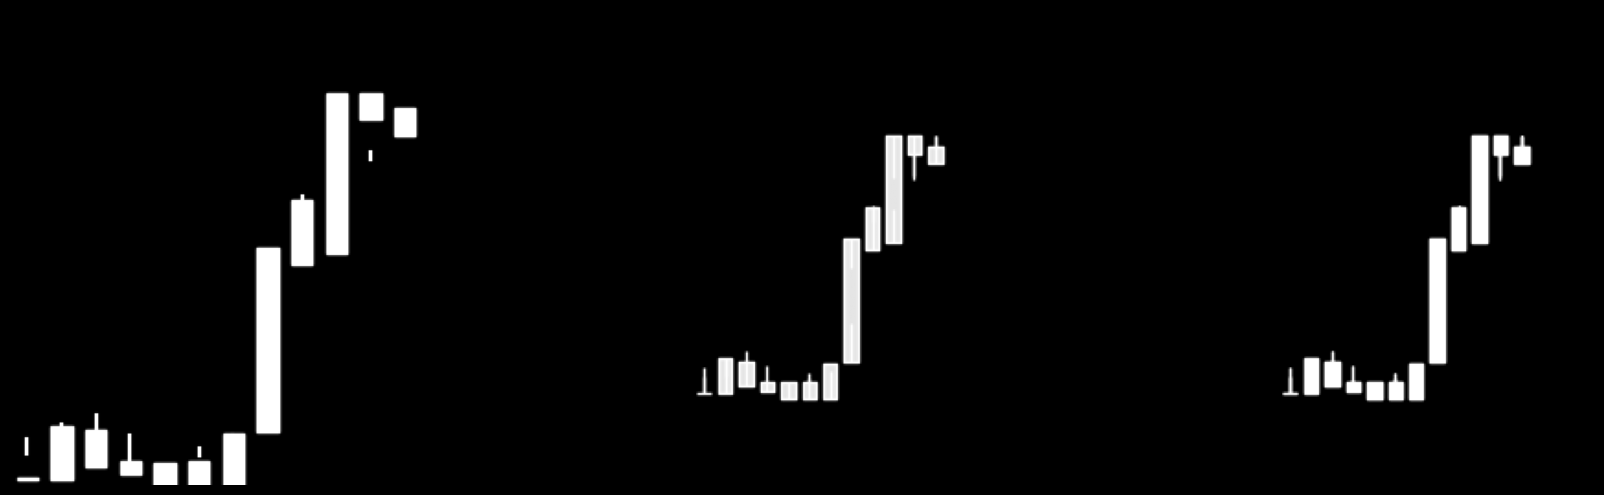

In [ ]:
# ============================================
# Phase 1 - Step 3-3 이미지 생성 방법 비교 (수정 버전)
# ============================================

!pip install mplfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
from PIL import Image

# 샘플 데이터 로드
PROCESSED_PATH = '/content/drive/MyDrive/Patron/data/processed'
sample = np.load(f"{PROCESSED_PATH}/TSLA.npy")[39]

print(f"입력 데이터: {sample.shape}")
print(f"값 범위: {sample.min():.3f} ~ {sample.max():.3f}\n")

# ============================================
# 방법 1: matplotlib (수정됨!)
# ============================================

def ohlc_to_image_matplotlib(ohlc_data):
    """matplotlib로 캔들스틱 그리기"""
    fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)

    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    for i in range(len(ohlc_data)):
        open_price = ohlc_data[i][0]
        high = ohlc_data[i][1]
        low = ohlc_data[i][2]
        close = ohlc_data[i][3]

        ax.plot([i, i], [low, high], color='white', linewidth=1.5)

        rect_height = close - open_price
        rect = plt.Rectangle((i-0.3, open_price), 0.6, rect_height,
                              facecolor='white', edgecolor='white')
        ax.add_patch(rect)

    ax.axis('off')
    ax.set_xlim(-0.5, len(ohlc_data)-0.5)
    ax.set_ylim(ohlc_data[:, 2].min()*0.95, ohlc_data[:, 1].max()*1.05)
    plt.tight_layout(pad=0)

    # 파일로 저장 (안전)
    fig.savefig('temp_matplotlib.png', facecolor='black',
                bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # 읽기
    img = Image.open('temp_matplotlib.png').convert('L')
    img_resized = img.resize((224, 224), Image.LANCZOS)

    return np.array(img_resized)

# ============================================
# 방법 2: mplfinance
# ============================================

def ohlc_to_image_mpf(ohlc_data, enhance_contrast=False):
    """mplfinance로 캔들스틱 그리기"""
    df = pd.DataFrame(ohlc_data, columns=['Open', 'High', 'Low', 'Close'])
    df.index = pd.date_range('2020-01-01', periods=len(df), freq='W')

    mc = mpf.make_marketcolors(up='white', down='white',
                                edge='white', wick='white')
    s = mpf.make_mpf_style(marketcolors=mc,
                            gridstyle='',
                            y_on_right=False,
                            facecolor='black',
                            figcolor='black')

    mpf.plot(df, type='candle', style=s,
             savefig='temp_mpf.png',
             figsize=(2.24, 2.24),
             axisoff=True)

    img = Image.open('temp_mpf.png').convert('L')
    img_resized = img.resize((224, 224), Image.LANCZOS)

    # 대비 증가 (옵션)
    if enhance_contrast:
        from PIL import ImageEnhance
        enhancer = ImageEnhance.Contrast(img_resized)
        img_resized = enhancer.enhance(1.5)  # 1.5배 증가

    return np.array(img_resized)

# ============================================
# 이미지 생성
# ============================================

print("🎨 이미지 생성 중...")
img1 = ohlc_to_image_matplotlib(sample)
img2 = ohlc_to_image_mpf(sample, enhance_contrast=False)  # 원본
img3 = ohlc_to_image_mpf(sample, enhance_contrast=True)   # 대비 증가

print(f"✅ matplotlib: {img1.shape}")
print(f"✅ mplfinance (원본): {img2.shape}")
print(f"✅ mplfinance (대비↑): {img3.shape}\n")

# ============================================
# 비교 시각화 (3개)
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('matplotlib (꼬리 끊김)', fontsize=14, weight='bold')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('mplfinance (원본)', fontsize=14, weight='bold')
axes[1].axis('off')

axes[2].imshow(img3, cmap='gray')
axes[2].set_title('mplfinance (대비 1.5배)', fontsize=14, weight='bold')
axes[2].axis('off')

plt.suptitle('TSLA 패턴 비교 (3가지 방법)', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


## 7. 전체 패턴 이미지 변환

약 50,000개 패턴을 224×224 그레이스케일 캔들스틱 이미지로 변환해 종목별 `.npy` 파일로 저장한다.

Google Drive I/O 병목을 피하기 위해 Colab 로컬 저장소(`/content/data`)를 사용한다. 메모리 부족을 막기 위해 100개 처리마다 가비지 컬렉션을 실행하고, 종목 단위로도 메모리를 해제한다.

✅ 입력 경로: /content/drive/MyDrive/Patron/data/processed
✅ 출력 경로: /content/drive/MyDrive/Patron/data/images
✅ 임시 파일: /content/temp_chart.png

🚀 Patron 이미지 변환 시작!

📊 총 172개 종목 발견
🎯 예상 이미지 개수: ~49,823개
⏭️  중복 건너뛰기: ON



🔄 종목별 변환: 100%|██████████| 172/172 [20:47<00:00,  7.25s/ticker, 성공=8353, 건너뜀=41634, 실패=0]



🎉 변환 완료!
✅ 신규 생성: 8,353개
⏭️  건너뜀: 41,634개
❌ 실패: 0개
📊 총계: 49,987개

🔍 샘플 5개 검증

📂 COF_70.npy
   Shape: (224, 224)
   Min: 0, Max: 255

📂 AMD_119.npy
   Shape: (224, 224)
   Min: 0, Max: 255

📂 LLY_39.npy
   Shape: (224, 224)
   Min: 0, Max: 255

📂 TTD_101.npy
   Shape: (224, 224)
   Min: 0, Max: 255

📂 UNP_71.npy
   Shape: (224, 224)
   Min: 0, Max: 255



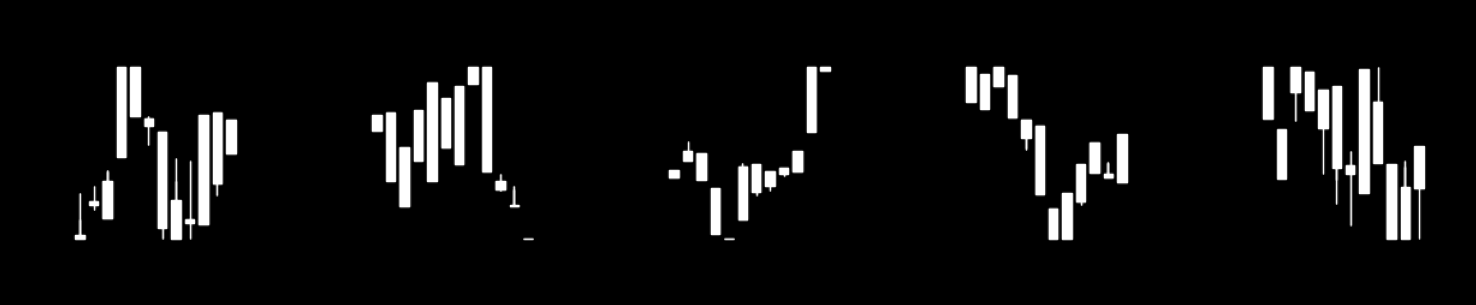


✨ 모든 작업 완료!


In [ ]:
# ============================================================
# Patron 프로젝트: 49,823개 패턴을 224x224 그레이스케일 이미지로 변환
# 메모리 최적화 버전 (RAM 부족 방지)
# ============================================================

import os
import gc  # ← 추가!
import numpy as np
import pandas as pd
import mplfinance as mpf
from PIL import Image, ImageEnhance
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. 경로 설정
# ============================================================
INPUT_DIR = '/content/drive/MyDrive/Patron/data/processed'
OUTPUT_DIR = '/content/drive/MyDrive/Patron/data/images'
TEMP_IMG = '/content/temp_chart.png'

# 출력 디렉토리 생성
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ 입력 경로: {INPUT_DIR}")
print(f"✅ 출력 경로: {OUTPUT_DIR}")
print(f"✅ 임시 파일: {TEMP_IMG}\n")

# ============================================================
# 2. 이미지 생성 함수 (대비 1.5배 + 메모리 해제)
# ============================================================
def ohlc_to_grayscale_image(ohlc_array, temp_path=TEMP_IMG):
    """
    (12, 4) OHLC numpy 배열 → (224, 224) 그레이스케일 numpy 배열
    """
    try:
        # DataFrame 생성
        df = pd.DataFrame(ohlc_array, columns=['Open', 'High', 'Low', 'Close'])
        df.index = pd.date_range('2020-01-01', periods=len(df), freq='W')

        # mplfinance 스타일
        mc = mpf.make_marketcolors(
            up='white', down='white',
            edge='white', wick='white',
            volume='white'
        )

        s = mpf.make_mpf_style(
            marketcolors=mc,
            gridstyle='',
            y_on_right=False,
            facecolor='black',
            figcolor='black'
        )

        # 임시 PNG 저장
        mpf.plot(
            df, type='candle', style=s,
            savefig=temp_path,
            figsize=(2.24, 2.24),
            axisoff=True,
            closefig=True
        )

        # PNG → 그레이스케일 → 대비 증가
        img = Image.open(temp_path).convert('L')
        img_resized = img.resize((224, 224), Image.LANCZOS)
        enhancer = ImageEnhance.Contrast(img_resized)
        img_enhanced = enhancer.enhance(1.5)

        img_array = np.array(img_enhanced, dtype=np.uint8)

        # 명시적 메모리 해제
        img.close()
        img_resized.close()
        del img, img_resized, img_enhanced, enhancer, df

        # 임시 파일 삭제
        if os.path.exists(temp_path):
            os.remove(temp_path)

        return img_array

    except Exception as e:
        print(f"⚠️ 이미지 생성 실패: {e}")
        return None

# ============================================================
# 3. 전체 데이터셋 변환 (메모리 최적화!)
# ============================================================
def convert_all_patterns(skip_existing=True):
    """
    172개 .npy 파일 → 49,823개 이미지 생성
    """
    npy_files = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith('.npy')])

    print(f"📊 총 {len(npy_files)}개 종목 발견")
    print(f"🎯 예상 이미지 개수: ~49,823개")
    print(f"⏭️  중복 건너뛰기: {'ON' if skip_existing else 'OFF'}\n")

    total_success = 0
    total_fail = 0
    total_skip = 0
    failed_patterns = []

    with tqdm(total=len(npy_files), desc="🔄 종목별 변환", unit="ticker") as pbar:
        for npy_file in npy_files:
            ticker = npy_file.replace('.npy', '')
            npy_path = os.path.join(INPUT_DIR, npy_file)

            # (N, 12, 4) 로드
            patterns = np.load(npy_path)
            num_patterns = len(patterns)

            # 패턴별 변환
            for i in range(num_patterns):
                output_filename = f"{ticker}_{i}.npy"
                output_path = os.path.join(OUTPUT_DIR, output_filename)

                # 중복 체크
                if skip_existing and os.path.exists(output_path):
                    total_skip += 1
                    continue

                # 이미지 생성
                pattern = patterns[i]
                img_array = ohlc_to_grayscale_image(pattern)

                if img_array is not None:
                    np.save(output_path, img_array)
                    total_success += 1
                else:
                    total_fail += 1
                    failed_patterns.append(output_filename)

                # ============================================================
                # 메모리 정리: 100개마다
                # ============================================================
                if (total_success + total_fail) % 100 == 0:
                    gc.collect()

            # 종목 하나 끝날 때마다 정리
            del patterns
            gc.collect()

            pbar.update(1)
            pbar.set_postfix({
                '성공': total_success,
                '건너뜀': total_skip,
                '실패': total_fail
            })

    # 결과 요약
    print("\n" + "="*60)
    print("🎉 변환 완료!")
    print("="*60)
    print(f"✅ 신규 생성: {total_success:,}개")
    print(f"⏭️  건너뜀: {total_skip:,}개")
    print(f"❌ 실패: {total_fail}개")
    print(f"📊 총계: {total_success + total_skip + total_fail:,}개")

    if failed_patterns:
        print(f"\n⚠️ 실패한 패턴 (처음 10개):")
        for fail in failed_patterns[:10]:
            print(f"  - {fail}")

    return total_success, total_skip, total_fail

# ============================================================
# 4. 샘플 검증
# ============================================================
def validate_samples(n_samples=5):
    """랜덤 샘플 시각화"""
    import matplotlib.pyplot as plt

    img_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.npy')]

    if len(img_files) == 0:
        print("⚠️ 이미지가 없습니다!")
        return

    samples = np.random.choice(img_files, min(n_samples, len(img_files)), replace=False)

    print(f"\n🔍 샘플 {len(samples)}개 검증\n")

    fig, axes = plt.subplots(1, len(samples), figsize=(15, 3))
    if len(samples) == 1:
        axes = [axes]

    for idx, img_file in enumerate(samples):
        img_path = os.path.join(OUTPUT_DIR, img_file)
        img_array = np.load(img_path)

        print(f"📂 {img_file}")
        print(f"   Shape: {img_array.shape}")
        print(f"   Min: {img_array.min()}, Max: {img_array.max()}\n")

        axes[idx].imshow(img_array, cmap='gray')
        axes[idx].set_title(img_file, fontsize=8)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. 실행
# ============================================================
if __name__ == "__main__":
    print("🚀 Patron 이미지 변환 시작!\n")

    # 변환 실행
    success, skip, fail = convert_all_patterns(skip_existing=True)

    # 샘플 검증
    if success + skip > 0:
        validate_samples(n_samples=5)

    print("\n✨ 모든 작업 완료!")